# Figure 2: Metabolic Rate Distribution by Vessel and Time of Day ('Environment')

This notebook isolates the code needed to reproduce the Figure 1 box-and-whisker chart


The data file required is batch_summary.csv which is produced in the notebook A_batch_respirometry_final.ipynb

## Load in batch_summary.csv and style code

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them. These trials
# yielded negative respiration rates and are not included in the main analysis, but they are included 
# here for completeness. During those trials, our seawater filter clogged and we used unfiltered seawater, 
# which likely introduced contaminants that affected the calculation of respiration rates.

use_unfiltered = False

# Locate the processed batch summary from common notebook working directories.
candidate_paths = [
    Path.cwd() / "../data/processed/batch_summary.csv",
    Path.cwd() / "data/processed/batch_summary.csv",
    Path("/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv"),
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/processed/batch_summary.csv")

agg_df = pd.read_csv(data_path)
print(f"Loaded {len(agg_df)} rows from {data_path}")

Loaded 71 rows from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


In [2]:
# Load shared Figure style + palette
from pathlib import Path
import importlib.util

style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

print(f'Shared style loaded from: {style_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle


## Statistics associated with the figure

In [3]:
# Linear-model contrasts focused on cylinder-night vs all other groups
# Hypothesis of interest: cylinder-night is higher than each other vessel/time combination.

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.multitest import multipletests
except ImportError:
    print("statsmodels is required for this cell. Install with: pip install statsmodels")
else:
    # Reuse plot_df if it exists; otherwise recreate from agg_df.
    if 'plot_df' in locals() and not plot_df.empty:
        stats_input = plot_df.copy()
    elif 'agg_df' in locals() and not agg_df.empty:
        stats_input = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()
    else:
        stats_input = pd.DataFrame()

    if stats_input.empty:
        print("No data available for statistics.")
    else:
        required_cols = {'vessel', 'environment', 'RMR'}
        missing = required_cols - set(stats_input.columns)
        if missing:
            print(f"Missing required columns for modeling: {sorted(missing)}")
        else:
            dat = stats_input.dropna(subset=['vessel', 'environment', 'RMR']).copy()
            dat['group_label'] = dat['vessel'].astype(str) + '_' + dat['environment'].astype(str)

            reference_group = 'cylinder_night'
            if reference_group not in set(dat['group_label']):
                print(f"Reference group '{reference_group}' not found. Available groups: {sorted(dat['group_label'].unique())}")
            else:
                # OLS with cylinder_night as reference and heteroskedasticity-robust SE.
                model = smf.ols(
                    "RMR ~ C(group_label, Treatment(reference='cylinder_night'))",
                    data=dat,
                ).fit(cov_type='HC3')

                group_means = dat.groupby('group_label')['RMR'].mean()
                group_ns = dat.groupby('group_label')['RMR'].size()
                ref_mean = group_means[reference_group]

                rows = []
                tested_terms = []
                tested_pvals_one_sided = []

                for group in sorted(group_means.index):
                    if group == reference_group:
                        continue

                    term = f"C(group_label, Treatment(reference='cylinder_night'))[T.{group}]"
                    if term not in model.params.index:
                        continue

                    # Coefficient is (group - cylinder_night).
                    coef_group_minus_ref = model.params[term]
                    p_two_sided = float(model.pvalues[term])

                    # One-sided p for H1: cylinder_night > group  <=>  (group - cylinder_night) < 0.
                    if coef_group_minus_ref < 0:
                        p_one_sided = p_two_sided / 2.0
                    else:
                        p_one_sided = 1.0 - (p_two_sided / 2.0)

                    tested_terms.append(group)
                    tested_pvals_one_sided.append(p_one_sided)

                    rows.append({
                        'comparison': f"cylinder_night vs {group}",
                        'n_cylinder_night': int(group_ns[reference_group]),
                        'n_group': int(group_ns[group]),
                        'mean_cylinder_night': float(ref_mean),
                        'mean_group': float(group_means[group]),
                        'diff_cylinder_minus_group': float(-coef_group_minus_ref),
                        'p_two_sided': p_two_sided,
                        'p_one_sided_cyl_gt_group': p_one_sided,
                    })

                if not rows:
                    print("No non-reference groups found for comparison.")
                else:
                    # Holm correction on one-sided p-values for the family of cylinder-night contrasts.
                    reject, p_holm, _, _ = multipletests(tested_pvals_one_sided, alpha=0.05, method='holm')

                    for i, row in enumerate(rows):
                        row['p_one_sided_holm'] = float(p_holm[i])
                        row['significant_holm_0.05'] = bool(reject[i])

                    contrast_df = pd.DataFrame(rows).sort_values('comparison').reset_index(drop=True)

                    print("Model: OLS with HC3 robust SE")
                    print("Formula: RMR ~ C(group_label), reference = cylinder_night")
                    print("Hypothesis test direction: cylinder_night > comparison group")
                    display(contrast_df)

                    print("\nCaption-ready statistics sentence:")
                    sig_count = int(contrast_df['significant_holm_0.05'].sum())
                    total_count = len(contrast_df)
                    print(
                        f"Cylinder-night metabolic rate was significantly higher than {sig_count} of {total_count} "
                        f"other vessel/time groups (one-sided contrasts from OLS with HC3 SE, Holm-corrected)."
                    )

Model: OLS with HC3 robust SE
Formula: RMR ~ C(group_label), reference = cylinder_night
Hypothesis test direction: cylinder_night > comparison group


,comparison,n_cylinder_night,n_group,mean_cylinder_night,mean_group,diff_cylinder_minus_group,p_two_sided,p_one_sided_cyl_gt_group,p_one_sided_holm,significant_holm_0.05
0,cylinder_night vs medium_night,8,6,5.844194,3.614779,2.229415,3.006731e-02,1.503366e-02,1.503366e-02,True
1,cylinder_night vs small_day,8,18,5.844194,1.181223,4.662971,6.524617e-07,3.262308e-07,9.786925e-07,True
2,cylinder_night vs small_night,8,26,5.844194,2.097811,3.746383,7.633049e-05,3.816524e-05,7.633049e-05,True



Caption-ready statistics sentence:
Cylinder-night metabolic rate was significantly higher than 3 of 3 other vessel/time groups (one-sided contrasts from OLS with HC3 SE, Holm-corrected).


## Create the figure in addition to summary statistics


Summary statistics by group:


count      mean       std       min       max
vessel   environment                                               
cylinder night            8  5.844194  2.439238  2.897411  8.546660
medium   night            6  3.614779  1.015635  2.521120  5.398751
small    day             18  1.181223  0.696188  0.375336  2.995435
         night           26  2.097811  1.084139  0.384284  4.356231

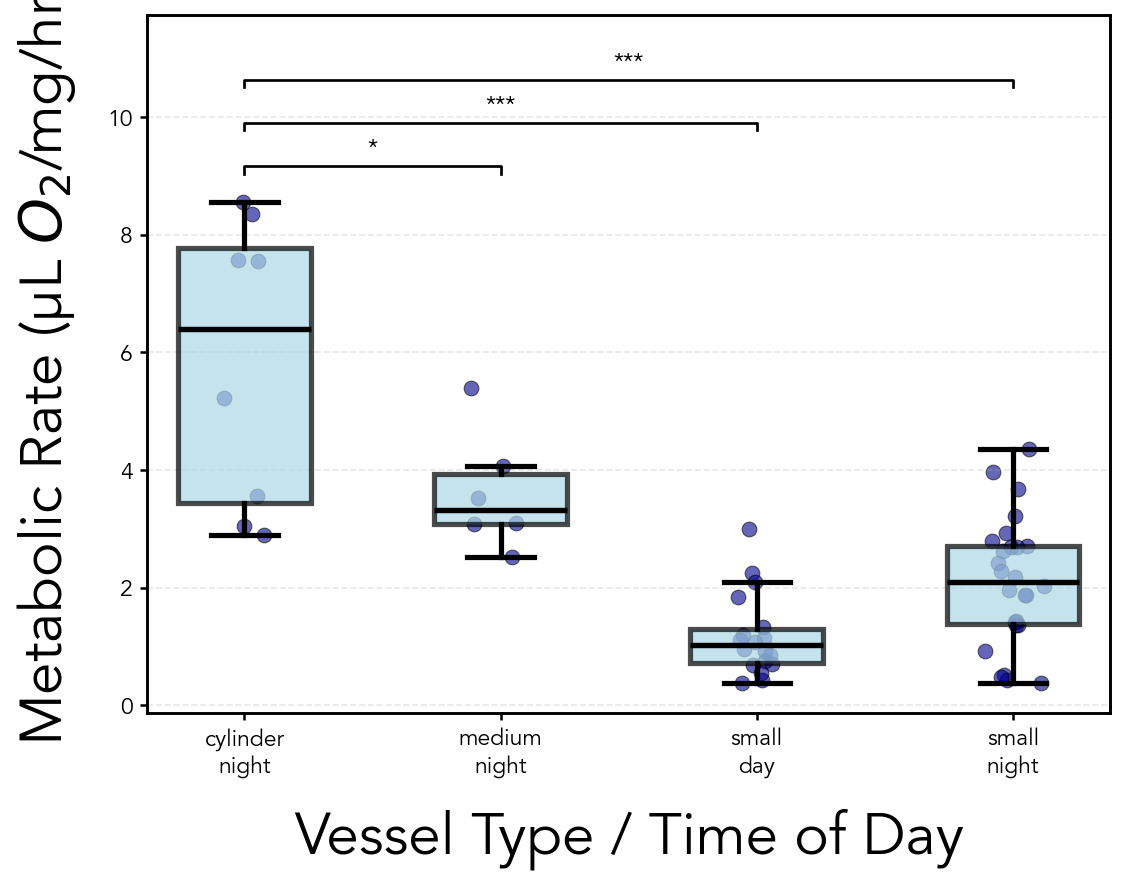

In [4]:
if 'agg_df' in locals() and not agg_df.empty:
    # Apply filtering based on toggle.
    plot_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

    # Group by vessel and environment if those columns exist.
    group_cols = [col for col in ['vessel', 'environment'] if col in plot_df.columns]

    if group_cols:
        stats = plot_df.groupby(group_cols)['RMR'].agg(['count', 'mean', 'std', 'min', 'max'])
        print("\nSummary statistics by group:")
        display(stats)

        plot_df['group'] = plot_df['vessel'] + '\n' + plot_df['environment']
        groups = sorted(plot_df['group'].unique())
        data_by_group = [plot_df[plot_df['group'] == g]['RMR'].values for g in groups]

        # Keep boxes narrow but place category centers closer together.
        positions = np.arange(len(groups)) * 0.58

        # Make canvas width proportional to number of groups so whitespace stays compact.
        fig_width = max(6.5, 1.55 * len(groups) + 1.4)
        fig, ax = plt.subplots(figsize=(fig_width, 6))

        bp = ax.boxplot(
            data_by_group,
            positions=positions,
            tick_labels=groups,
            patch_artist=True,
            widths=0.30,
            showfliers=False,
            boxprops=dict(linewidth=2.5, color='black'),
            whiskerprops=dict(linewidth=2.5, color='black'),
            capprops=dict(linewidth=2.5, color='black'),
            medianprops=dict(linewidth=2.6, color='black'),
        )
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)

        for i, group in enumerate(groups):
            y_data = plot_df[plot_df['group'] == group]['RMR'].values
            x_data = np.random.normal(positions[i], 0.03, size=len(y_data))
            ax.scatter(
                x_data,
                y_data,
                alpha=0.6,
                s=50,
                c='darkblue',
                edgecolors='black',
                linewidth=0.5,
            )

        # Add significance brackets from cylinder-night to each other group if model contrasts are available.
        if 'contrast_df' in locals() and not contrast_df.empty:
            x_lookup = {g: positions[i] for i, g in enumerate(groups)}
            ref_label = 'cylinder\nnight'

            if ref_label in x_lookup:
                ref_x = x_lookup[ref_label]
                y_min = float(np.nanmin(plot_df['RMR'].values))
                y_max = float(np.nanmax(plot_df['RMR'].values))
                y_range = y_max - y_min
                if y_range <= 0:
                    y_range = max(abs(y_max), 1.0)

                bracket_base = y_max + 0.06 * y_range
                bracket_step = 0.09 * y_range
                bracket_tick = 0.015 * y_range

                # Build rows with plotting positions, then order by distance from reference
                # so brackets stack from closest -> middle -> farthest.
                bracket_rows = []
                for _, row in contrast_df.iterrows():
                    group_label = row['comparison'].split(' vs ')[1]
                    comp_label = group_label.replace('_', '\n', 1)
                    if comp_label not in x_lookup:
                        continue
                    comp_x = x_lookup[comp_label]
                    distance = abs(comp_x - ref_x)
                    bracket_rows.append((distance, comp_label, comp_x, row))

                bracket_rows.sort(key=lambda item: item[0])

                used = 0
                for _, _, comp_x, row in bracket_rows:
                    y = bracket_base + used * bracket_step

                    ax.plot(
                        [ref_x, ref_x, comp_x, comp_x],
                        [y, y + bracket_tick, y + bracket_tick, y],
                        color='black',
                        linewidth=1.3,
                    )

                    p_adj = float(row['p_one_sided_holm'])
                    if p_adj < 0.001:
                        stars = '***'
                    elif p_adj < 0.01:
                        stars = '**'
                    elif p_adj < 0.05:
                        stars = '*'
                    else:
                        stars = 'ns'

                    ax.text(
                        (ref_x + comp_x) / 2,
                        y + bracket_tick + 0.01 * y_range,
                        stars,
                        ha='center',
                        va='bottom',
                        fontsize=11,
                        fontweight='bold',
                    )
                    used += 1

                if used > 0:
                    ax.set_ylim(top=bracket_base + used * bracket_step + 0.06 * y_range)

        ax.set_xticks(positions)
        ax.set_xticklabels(groups)
        ax.set_ylabel('Metabolic Rate (µL $O_2$/mg/hr)', fontsize=28, fontweight='bold', labelpad=14)
        ax.set_xlabel('Vessel Type / Time of Day', fontsize=28, fontweight='bold', labelpad=14)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Tighten side whitespace around first and last categories.
        ax.set_xlim(positions[0] - 0.22, positions[-1] + 0.22)

        plt.xticks(rotation=0, ha='center')
        plt.tight_layout()
        plt.show()
    else:
        print("\nOverall statistics:")
        print(plot_df['RMR'].describe())
else:
    print('No data available for statistics.')

In [5]:
# Save Figure 1 to files
from pathlib import Path

figures_dir = Path.cwd() / "../figures"
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    png_path = (figures_dir / 'Figure1_BarChart.png').resolve()
    pdf_path = (figures_dir / 'Figure1_BarChart.pdf').resolve()

    fig.savefig(png_path, dpi=600, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")
else:
    print("No figure object found. Run the plotting cell first.")

Saved PNG: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure1_BarChart.png
Saved PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure1_BarChart.pdf


## Re-run with all data including filtered


Summary statistics by group (all data):


count      mean       std       min       max
vessel   environment                                               
cylinder night           10  4.680861  3.262872 -0.103040  8.546660
medium   night            6  3.614779  1.015635  2.521120  5.398751
small    day             23  1.192808  0.644553  0.375336  2.995435
         night           32  1.908178  1.059100  0.384284  4.356231


All-data contrast statistics (cylinder_night > others):


,comparison,n_cylinder_night,n_group,mean_cylinder_night,mean_group,diff_cylinder_minus_group,p_two_sided,p_one_sided_cyl_gt_group,p_one_sided_holm,significant_holm_0.05
0,cylinder_night vs medium_night,10,6,4.680861,3.614779,1.066082,0.365736,0.182868,0.182868,False
1,cylinder_night vs small_day,10,23,4.680861,1.192808,3.488053,0.001464,0.000732,0.002196,True
2,cylinder_night vs small_night,10,32,4.680861,1.908178,2.772682,0.012033,0.006016,0.012033,True


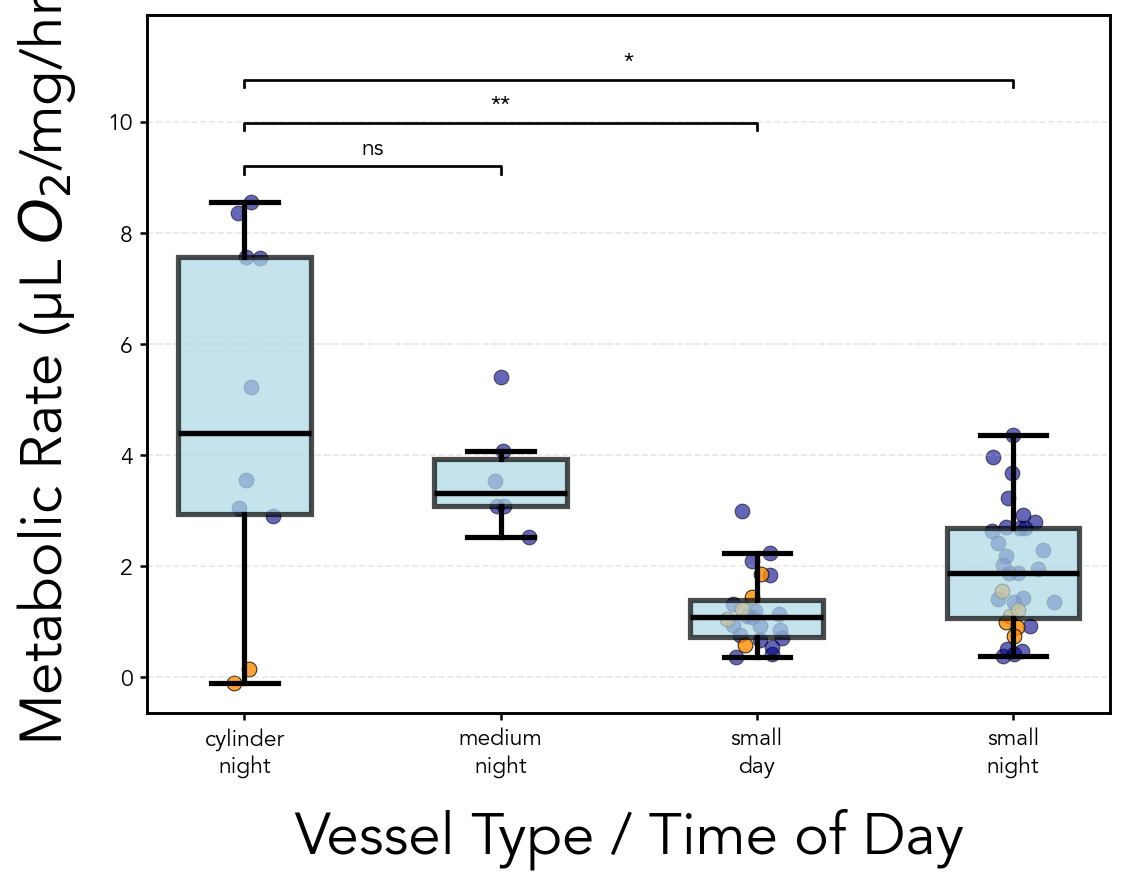


Completed all-data plot + descriptive statistics table (including filtered=False rows).


In [6]:
# Re-run Figure 1 workflow with ALL rows (including filtered=False rows).
try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.multitest import multipletests
except ImportError:
    print("statsmodels is required for this cell. Install with: pip install statsmodels")
else:
    if 'agg_df' not in locals() or agg_df.empty:
        print('No data available for all-data rerun.')
    else:
        plot_df_all = agg_df.copy()
        required_cols = {'vessel', 'environment', 'RMR'}
        missing = required_cols - set(plot_df_all.columns)
        if missing:
            print(f"Missing required columns: {sorted(missing)}")
        else:
            # Descriptive statistics table (all data).
            stats_all = plot_df_all.groupby(['vessel', 'environment'])['RMR'].agg(['count', 'mean', 'std', 'min', 'max'])
            print("\nSummary statistics by group (all data):")
            display(stats_all)

            # Recompute contrasts on all data so brackets match this plot.
            dat_all = plot_df_all.dropna(subset=['vessel', 'environment', 'RMR']).copy()
            dat_all['group_label'] = dat_all['vessel'].astype(str) + '_' + dat_all['environment'].astype(str)

            reference_group = 'cylinder_night'
            contrast_df_all = pd.DataFrame()

            if reference_group in set(dat_all['group_label']):
                model_all = smf.ols(
                    "RMR ~ C(group_label, Treatment(reference='cylinder_night'))",
                    data=dat_all,
                ).fit(cov_type='HC3')

                group_means_all = dat_all.groupby('group_label')['RMR'].mean()
                group_ns_all = dat_all.groupby('group_label')['RMR'].size()
                ref_mean_all = group_means_all[reference_group]

                rows_all = []
                tested_terms_all = []
                tested_pvals_one_sided_all = []

                for group in sorted(group_means_all.index):
                    if group == reference_group:
                        continue
                    term = f"C(group_label, Treatment(reference='cylinder_night'))[T.{group}]"
                    if term not in model_all.params.index:
                        continue

                    coef_group_minus_ref = model_all.params[term]
                    p_two_sided = float(model_all.pvalues[term])
                    p_one_sided = p_two_sided / 2.0 if coef_group_minus_ref < 0 else 1.0 - (p_two_sided / 2.0)

                    tested_terms_all.append(group)
                    tested_pvals_one_sided_all.append(p_one_sided)

                    rows_all.append({
                        'comparison': f"cylinder_night vs {group}",
                        'n_cylinder_night': int(group_ns_all[reference_group]),
                        'n_group': int(group_ns_all[group]),
                        'mean_cylinder_night': float(ref_mean_all),
                        'mean_group': float(group_means_all[group]),
                        'diff_cylinder_minus_group': float(-coef_group_minus_ref),
                        'p_two_sided': p_two_sided,
                        'p_one_sided_cyl_gt_group': p_one_sided,
                    })

                if rows_all:
                    reject_all, p_holm_all, _, _ = multipletests(tested_pvals_one_sided_all, alpha=0.05, method='holm')
                    for i, row in enumerate(rows_all):
                        row['p_one_sided_holm'] = float(p_holm_all[i])
                        row['significant_holm_0.05'] = bool(reject_all[i])
                    contrast_df_all = pd.DataFrame(rows_all).sort_values('comparison').reset_index(drop=True)
                    print("\nAll-data contrast statistics (cylinder_night > others):")
                    display(contrast_df_all)

            # Build the plot exactly as above, but using all-data table.
            plot_df_all['group'] = plot_df_all['vessel'] + '\n' + plot_df_all['environment']
            groups_all = sorted(plot_df_all['group'].unique())
            data_by_group_all = [plot_df_all[plot_df_all['group'] == g]['RMR'].values for g in groups_all]

            positions_all = np.arange(len(groups_all)) * 0.58
            fig_width_all = max(6.5, 1.55 * len(groups_all) + 1.4)
            fig_all, ax_all = plt.subplots(figsize=(fig_width_all, 6))

            bp_all = ax_all.boxplot(
                data_by_group_all,
                positions=positions_all,
                tick_labels=groups_all,
                patch_artist=True,
                widths=0.30,
                showfliers=False,
                boxprops=dict(linewidth=2.5, color='black'),
                whiskerprops=dict(linewidth=2.5, color='black'),
                capprops=dict(linewidth=2.5, color='black'),
                medianprops=dict(linewidth=2.6, color='black'),
            )
            for patch in bp_all['boxes']:
                patch.set_facecolor('lightblue')
                patch.set_alpha(0.7)

            for i, group in enumerate(groups_all):
                group_df = plot_df_all[plot_df_all['group'] == group].copy()
                x_data = np.random.normal(positions_all[i], 0.03, size=len(group_df))

                if 'filtered' in group_df.columns:
                    excluded_mask = group_df['filtered'].fillna(True) == False
                else:
                    excluded_mask = pd.Series(False, index=group_df.index)

                included_mask = ~excluded_mask

                if included_mask.any():
                    ax_all.scatter(
                        x_data[included_mask.to_numpy()],
                        group_df.loc[included_mask, 'RMR'].to_numpy(),
                        alpha=0.6,
                        s=50,
                        c='darkblue',
                        edgecolors='black',
                        linewidth=0.5,
                    )

                if excluded_mask.any():
                    ax_all.scatter(
                        x_data[excluded_mask.to_numpy()],
                        group_df.loc[excluded_mask, 'RMR'].to_numpy(),
                        alpha=0.8,
                        s=50,
                        c='darkorange',
                        edgecolors='black',
                        linewidth=0.5,
                    )

            # Add all-data significance brackets if contrasts are available.
            if not contrast_df_all.empty:
                x_lookup_all = {g: positions_all[i] for i, g in enumerate(groups_all)}
                ref_label = 'cylinder\nnight'

                if ref_label in x_lookup_all:
                    ref_x = x_lookup_all[ref_label]
                    y_min = float(np.nanmin(plot_df_all['RMR'].values))
                    y_max = float(np.nanmax(plot_df_all['RMR'].values))
                    y_range = y_max - y_min
                    if y_range <= 0:
                        y_range = max(abs(y_max), 1.0)

                    bracket_base = y_max + 0.06 * y_range
                    bracket_step = 0.09 * y_range
                    bracket_tick = 0.015 * y_range

                    bracket_rows = []
                    for _, row in contrast_df_all.iterrows():
                        group_label = row['comparison'].split(' vs ')[1]
                        comp_label = group_label.replace('_', '\n', 1)
                        if comp_label not in x_lookup_all:
                            continue
                        comp_x = x_lookup_all[comp_label]
                        distance = abs(comp_x - ref_x)
                        bracket_rows.append((distance, comp_x, row))

                    bracket_rows.sort(key=lambda item: item[0])

                    used = 0
                    for _, comp_x, row in bracket_rows:
                        y = bracket_base + used * bracket_step
                        ax_all.plot(
                            [ref_x, ref_x, comp_x, comp_x],
                            [y, y + bracket_tick, y + bracket_tick, y],
                            color='black',
                            linewidth=1.3,
                        )

                        p_adj = float(row['p_one_sided_holm'])
                        if p_adj < 0.001:
                            stars = '***'
                        elif p_adj < 0.01:
                            stars = '**'
                        elif p_adj < 0.05:
                            stars = '*'
                        else:
                            stars = 'ns'

                        ax_all.text(
                            (ref_x + comp_x) / 2,
                            y + bracket_tick + 0.01 * y_range,
                            stars,
                            ha='center',
                            va='bottom',
                            fontsize=11,
                            fontweight='bold',
                        )
                        used += 1

                    if used > 0:
                        ax_all.set_ylim(top=bracket_base + used * bracket_step + 0.06 * y_range)

            ax_all.set_xticks(positions_all)
            ax_all.set_xticklabels(groups_all)
            ax_all.set_ylabel('Metabolic Rate (µL $O_2$/mg/hr)', fontsize=28, fontweight='bold', labelpad=14)
            ax_all.set_xlabel('Vessel Type / Time of Day', fontsize=28, fontweight='bold', labelpad=14)
            ax_all.grid(axis='y', alpha=0.3, linestyle='--')
            ax_all.set_xlim(positions_all[0] - 0.22, positions_all[-1] + 0.22)

            plt.xticks(rotation=0, ha='center')
            plt.tight_layout()
            plt.show()

            print('\nCompleted all-data plot + descriptive statistics table (including filtered=False rows).')

## Supplemental statistical analysis including temperature

In [7]:
# Temperature-adjusted sensitivity analysis for Fig. 2 treatment comparisons.
# Model: RMR ~ group + temp_C, with cylinder_night as the reference group.
# This keeps the same HC3 robust-SE framework and Holm correction as the main Fig. 2 statistics.

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.multitest import multipletests
except ImportError:
    print("statsmodels is required for this cell. Install with: pip install statsmodels")
else:
    if 'agg_df' not in locals() or agg_df.empty:
        print('No data available for temperature-adjusted sensitivity analysis.')
    else:
        temp_input = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()
        required_cols = {'vessel', 'environment', 'RMR', 'temp_C'}
        missing = required_cols - set(temp_input.columns)

        if missing:
            print(f"Missing required columns for temperature-adjusted model: {sorted(missing)}")
        else:
            temp_dat = temp_input.dropna(subset=['vessel', 'environment', 'RMR', 'temp_C']).copy()
            temp_dat['group_label'] = temp_dat['vessel'].astype(str) + '_' + temp_dat['environment'].astype(str)

            reference_group = 'cylinder_night'
            expected_groups = {'cylinder_night', 'medium_night', 'small_night', 'small_day'}
            present_groups = set(temp_dat['group_label'])
            missing_groups = expected_groups - present_groups

            if reference_group not in present_groups:
                print(f"Reference group '{reference_group}' not found. Available groups: {sorted(present_groups)}")
            elif missing_groups:
                print(f"Missing expected treatment groups: {sorted(missing_groups)}")
            else:
                temp_model = smf.ols(
                    "RMR ~ C(group_label, Treatment(reference='cylinder_night')) + temp_C",
                    data=temp_dat,
                ).fit(cov_type='HC3')

                # Refit the original no-temperature model on the exact same rows for side-by-side comparison.
                base_same_rows_model = smf.ols(
                    "RMR ~ C(group_label, Treatment(reference='cylinder_night'))",
                    data=temp_dat,
                ).fit(cov_type='HC3')

                group_means = temp_dat.groupby('group_label')['RMR'].mean()
                group_ns = temp_dat.groupby('group_label')['RMR'].size()
                ref_mean = group_means[reference_group]

                adjusted_rows = []
                unadjusted_rows = []
                tested_groups = []
                adjusted_one_sided_pvals = []
                unadjusted_one_sided_pvals = []

                for group in sorted(group_means.index):
                    if group == reference_group:
                        continue

                    term = f"C(group_label, Treatment(reference='cylinder_night'))[T.{group}]"
                    if term not in temp_model.params.index or term not in base_same_rows_model.params.index:
                        continue

                    tested_groups.append(group)

                    adjusted_coef_group_minus_ref = temp_model.params[term]
                    adjusted_p_two_sided = float(temp_model.pvalues[term])
                    adjusted_p_one_sided = (
                        adjusted_p_two_sided / 2.0
                        if adjusted_coef_group_minus_ref < 0
                        else 1.0 - (adjusted_p_two_sided / 2.0)
                    )
                    adjusted_one_sided_pvals.append(adjusted_p_one_sided)

                    base_coef_group_minus_ref = base_same_rows_model.params[term]
                    base_p_two_sided = float(base_same_rows_model.pvalues[term])
                    base_p_one_sided = (
                        base_p_two_sided / 2.0
                        if base_coef_group_minus_ref < 0
                        else 1.0 - (base_p_two_sided / 2.0)
                    )
                    unadjusted_one_sided_pvals.append(base_p_one_sided)

                    adjusted_rows.append({
                        'comparison': f"cylinder_night vs {group}",
                        'n_cylinder_night': int(group_ns[reference_group]),
                        'n_group': int(group_ns[group]),
                        'mean_cylinder_night': float(ref_mean),
                        'mean_group': float(group_means[group]),
                        'adjusted_diff_cylinder_minus_group': float(-adjusted_coef_group_minus_ref),
                        'adjusted_p_two_sided': adjusted_p_two_sided,
                        'adjusted_p_one_sided_cyl_gt_group': adjusted_p_one_sided,
                    })

                    unadjusted_rows.append({
                        'comparison': f"cylinder_night vs {group}",
                        'unadjusted_diff_cylinder_minus_group': float(-base_coef_group_minus_ref),
                        'unadjusted_p_one_sided_cyl_gt_group': base_p_one_sided,
                    })

                if not adjusted_rows:
                    print('No temperature-adjusted contrasts could be calculated.')
                else:
                    adjusted_reject, adjusted_p_holm, _, _ = multipletests(
                        adjusted_one_sided_pvals,
                        alpha=0.05,
                        method='holm',
                    )
                    unadjusted_reject, unadjusted_p_holm, _, _ = multipletests(
                        unadjusted_one_sided_pvals,
                        alpha=0.05,
                        method='holm',
                    )

                    for i, row in enumerate(adjusted_rows):
                        row['adjusted_p_one_sided_holm'] = float(adjusted_p_holm[i])
                        row['adjusted_significant_holm_0.05'] = bool(adjusted_reject[i])

                    for i, row in enumerate(unadjusted_rows):
                        row['unadjusted_p_one_sided_holm'] = float(unadjusted_p_holm[i])
                        row['unadjusted_significant_holm_0.05'] = bool(unadjusted_reject[i])

                    adjusted_contrast_df = pd.DataFrame(adjusted_rows)
                    unadjusted_same_rows_df = pd.DataFrame(unadjusted_rows)
                    fig2_temp_contrast_df = (
                        adjusted_contrast_df
                        .merge(unadjusted_same_rows_df, on='comparison', how='left')
                        .sort_values('comparison')
                        .reset_index(drop=True)
                    )

                    temp_coef_ci = temp_model.conf_int(alpha=0.05).loc['temp_C']
                    fig2_temp_covariate_df = pd.DataFrame({
                        'term': ['temp_C'],
                        'estimate': [float(temp_model.params['temp_C'])],
                        'std_error_HC3': [float(temp_model.bse['temp_C'])],
                        'p_value': [float(temp_model.pvalues['temp_C'])],
                        'ci95_lower': [float(temp_coef_ci[0])],
                        'ci95_upper': [float(temp_coef_ci[1])],
                    })

                    print('Table S2. Temperature-adjusted treatment model for Fig. 2 comparisons')
                    print('=' * 86)
                    print('Model: RMR ~ group + temp_C; reference group = cylinder_night; SE = HC3')
                    print('Hypothesis test direction: cylinder_night > comparison group; Holm correction applied')
                    display(fig2_temp_contrast_df)

                    print()
                    print('Temperature covariate in the sensitivity model')
                    print('=' * 86)
                    display(fig2_temp_covariate_df)

                    adjusted_sig_count = int(fig2_temp_contrast_df['adjusted_significant_holm_0.05'].sum())
                    unadjusted_sig_count = int(fig2_temp_contrast_df['unadjusted_significant_holm_0.05'].sum())
                    total_count = len(fig2_temp_contrast_df)
                    if adjusted_sig_count == unadjusted_sig_count:
                        qualitative_text = 'qualitatively unchanged'
                    else:
                        qualitative_text = 'similar but not identical'

                    print()
                    print('Results-ready sentence:')
                    print(
                        f"As a sensitivity analysis, we repeated the Fig. 2 treatment model with temperature included "
                        f"as a covariate. The cylinder-night contrasts remained {qualitative_text}: "
                        f"{adjusted_sig_count} of {total_count} contrasts were significant after HC3 robust SEs and Holm correction "
                        f"(compared with {unadjusted_sig_count} of {total_count} in the same-row model without temperature), "
                        f"indicating that the main vessel-treatment pattern was not explained by the small temperature variation among trials."
                    )

                    print()
                    print('Caution:')
                    print(
                        'The temp_C coefficient is reported only as a sensitivity covariate; temperature is partly confounded '
                        'with date, vessel type, and trial conditions, so this model is not a clean test of thermal sensitivity.'
                    )


Table S2. Temperature-adjusted treatment model for Fig. 2 comparisons
Model: RMR ~ group + temp_C; reference group = cylinder_night; SE = HC3
Hypothesis test direction: cylinder_night > comparison group; Holm correction applied


,comparison,n_cylinder_night,n_group,mean_cylinder_night,mean_group,adjusted_diff_cylinder_minus_group,adjusted_p_two_sided,adjusted_p_one_sided_cyl_gt_group,adjusted_p_one_sided_holm,adjusted_significant_holm_0.05,unadjusted_diff_cylinder_minus_group,unadjusted_p_one_sided_cyl_gt_group,unadjusted_p_one_sided_holm,unadjusted_significant_holm_0.05
0,cylinder_night vs medium_night,8,6,5.844194,3.614779,2.344082,0.014018,0.007009,0.007009,True,2.229415,1.503366e-02,1.503366e-02,True
1,cylinder_night vs small_day,8,18,5.844194,1.181223,3.566093,0.000091,0.000045,0.000091,True,4.662971,3.262308e-07,9.786925e-07,True
2,cylinder_night vs small_night,8,26,5.844194,2.097811,3.297433,0.000061,0.000030,0.000091,True,3.746383,3.816524e-05,7.633049e-05,True



Temperature covariate in the sensitivity model


,term,estimate,std_error_HC3,p_value,ci95_lower,ci95_upper
0,temp_C,0.755014,0.255005,0.003069,0.255214,1.254815



Results-ready sentence:
As a sensitivity analysis, we repeated the Fig. 2 treatment model with temperature included as a covariate. The cylinder-night contrasts remained qualitatively unchanged: 3 of 3 contrasts were significant after HC3 robust SEs and Holm correction (compared with 3 of 3 in the same-row model without temperature), indicating that the main vessel-treatment pattern was not explained by the small temperature variation among trials.

Caution:
The temp_C coefficient is reported only as a sensitivity covariate; temperature is partly confounded with date, vessel type, and trial conditions, so this model is not a clean test of thermal sensitivity.
